<table style="width: 100%; border-collapse: collapse; border: none;">
<tr>
<td style="border: 2px solid #1a2a6c; border-radius: 15px; background-color: #f8f9fa; padding: 40px; text-align: center;">
<h1 style="color: #1a2a6c; margin-bottom: 0px; font-size: 36px; font-family: sans-serif;">
<b>🚀 Retail Demand Forecasting</b>
</h1>
<p style="color: #666; font-style: italic; font-size: 18px; margin-top: 10px; font-family: sans-serif;">
Forecasting 2,000 retail sales time series with global machine learning models in Python (Darts)
</p>
<hr style="width: 50%; border: 0; border-top: 1px solid #ddd; margin: 20px auto;">
<div style="font-family: sans-serif; font-size: 16px;">
<span style="color: #333;">Author:</span>
<a href="https://github.com/LunaPerezT" style="color: #3498db; text-decoration: none; font-weight: bold;">Luna Pérez T.</a>
</div>
<br></br>
<div style="background-color: #1a2a6c; color: white; display: inline-block; padding: 10px 10px; border-radius: 5px; font-weight: bold; font-family: sans-serif;">
PART 2 : Preprocessing, Training and Evaluation of Machine Learning Models
</div>
</td>
</tr>
</table>

## **0. Importing the required libraries**

Throughout this notebook we use several libraries, both Python built-ins such as `time` and `joblib` and third-party ones such as numpy and pandas. For time series forecasting we use the functions and models of Darts. This library streamlines work with time series and saves a great deal of code. We also use a number of scikit-learn models that are not included in Darts but which we believe may give good results. Finally, we use the Optuna library to run Bayesian hyperparameter optimisation on the models with the best metrics.

In [ ]:
import warnings, time, os, joblib
import random
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import darts
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler, InvertibleMapper
from darts.dataprocessing.pipeline import Pipeline as DartsPipeline
from darts.metrics import rmsse, mase,mae,rmse,rmsle,smape,ope
from darts.models import GlobalNaiveSeasonal, LinearRegressionModel, LightGBMModel, XGBModel,RandomForestModel, CatBoostModel, SKLearnModel
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge, QuantileRegressor, PoissonRegressor, TweedieRegressor, HuberRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
import optuna
from optuna.samplers import TPESampler
from optuna.pruners  import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# Allows the notebook to run either from notebooks/ or from the repository root.
import os
from pathlib import Path

if not Path('data').is_dir() and Path('..', 'data').is_dir():
    os.chdir('..')
print('Working directory:', Path.cwd())

## **1. Data Processing and Construction of the Time Series**

With the EDA complete, we move on to the preprocessing needed to prepare the data for modelling.
We load directly the preprocessed dataframe generated at the end of **Part 1**, which already incorporates the merge with `prices.csv` and the long format required for modelling.

In [115]:
df_long = pd.read_parquet('./data/preprocessed_data.parquet')
df_long.head(3)

,unique_id,cat_id,store_id,subcat_id,product_id,ds,y,price,dow,month,year,doy
0,A_1_008_1,A,1,1,A_1_008,2013-01-01,1.0,1.30,1,1,2013,1
1,A_1_008_1,A,1,1,A_1_008,2013-01-02,1.0,1.42,2,1,2013,2
2,A_1_008_1,A,1,1,A_1_008,2013-01-03,0.0,1.69,3,1,2013,3


We set a number of global configuration variables: the random seed, and the horizon, which is 31 days — the same as both the forecast we have to produce and the test set. For validation during hyperparameter optimisation with Optuna we use the last 30 days, that is, the month of November.

In [ ]:
os.makedirs('models', exist_ok=True)

SEED = 42
np.random.seed(SEED);
HORIZON     = 31   # days to forecast (Jan 2016)
TEST_SIZE   = 31   # TEST (Dec 2015)
VAL_SIZE    = 30   # CV-Val (Nov 2015) — Optuna only

To train models in Darts we first need to build a `TimeSeries` object from our dataframe.

In [117]:
ts_dict  = {}
ts_all   = []

for uid, grp in df_long.groupby('unique_id'):
    ts = TimeSeries.from_dataframe(grp.sort_values('ds')[['ds','y']],time_col='ds', value_cols='y', freq='D')
    ts_dict[uid] = ts
    ts_all.append(ts)


We split the time series into the sections described above.

In [ ]:
ts_test   = [ts[-TEST_SIZE:]                          for ts in ts_all]   # Dec 2015
ts_train  = [ts[:-TEST_SIZE]                          for ts in ts_all]   # up to Nov 2015


print()
print(f'TRAIN    : {ts_train[0].start_time().date()} → {ts_train[0].end_time().date()}  ({len(ts_train[0])} days)')
print(f'TEST     : {ts_test[0].start_time().date()} → {ts_test[0].end_time().date()}  ({len(ts_test[0])} days)')
print(f'CV-TRAIN : {ts_cv_tr[0].start_time().date()} → {ts_cv_tr[0].end_time().date()} ({len(ts_cv_tr[0])} days)')
print(f'CV-VAL   : {ts_cv_val[0].start_time().date()} → {ts_cv_val[0].end_time().date()} ({len(ts_cv_val[0])} days)')


TRAIN    : 2013-01-01 → 2015-11-30  (1064 days)
TEST     : 2015-12-01 → 2015-12-31  (31 days)
CV-TRAIN : 2013-01-01 → 2015-10-31 (1034 days)
CV-VAL   : 2015-11-01 → 2015-11-30 (30 days)


First we build the future covariates: time series encoding the cyclical weekly, monthly and annual patterns. This lets the model learn these patterns. Because they are variables we know about the future — the day of the week, whether it is a weekend or Christmas — we can also feed them in at prediction time.

In [119]:
def build_calendar_covariates(start: str, end: str) -> TimeSeries:
    idx = pd.date_range(start='2013-01-01', end='2016-01-31', freq='D')
    df_cal = pd.DataFrame(index=idx)
    df_cal['dow_sin']    = np.sin(2*np.pi*idx.dayofweek/7)
    df_cal['dow_cos']    = np.cos(2*np.pi*idx.dayofweek/7)
    df_cal['month_sin']  = np.sin(2*np.pi*idx.month/12)
    df_cal['month_cos']  = np.cos(2*np.pi*idx.month/12)
    df_cal['doy_sin']    = np.sin(2*np.pi*idx.dayofyear/365)
    df_cal['doy_cos']    = np.cos(2*np.pi*idx.dayofyear/365)
    df_cal['is_weekend'] = (idx.dayofweek >= 5).astype(float)
    df_cal['month_norm'] = (idx.month - 1) / 11
    df_cal['trend']      = np.arange(len(idx)) / len(idx)
    df_cal['is_xmas']    = ((idx.month == 12) & (idx.day == 25)).astype(float)
    df_cal.index.name = 'ds'
    return TimeSeries.from_dataframe(df_cal.reset_index(), time_col='ds',value_cols=df_cal.columns.tolist(), freq='D')

calendar_cov   = build_calendar_covariates('2013-01-01', '2016-01-31')
future_cov_list = [calendar_cov] * len(ts_all)

Also, since as we saw there is some relationship between an item's price and its sales, we add price as a *past* covariate, because we cannot supply the price the items will have in the future.

In [120]:
past_cov_list = None
pcd = {}

for uid, grp in df_long.groupby('unique_id'):
    gs       = grp.sort_values('ds')[['ds', 'price']]
    pcd[uid] = TimeSeries.from_dataframe(gs, time_col='ds', value_cols='price', freq='D')

uids_ordered  = list(ts_dict.keys())
past_cov_list = [pcd[uid] for uid in uids_ordered]

In [121]:
META_DF = (df_long.drop_duplicates('unique_id')[['unique_id', 'cat_id', 'store_id', 'subcat_id', 'product_id']].reset_index(drop=True))
cat_dummies   = pd.get_dummies(META_DF.set_index('unique_id')['cat_id'].astype(str),prefix='cat', dtype=float)
store_dummies = pd.get_dummies(META_DF.set_index('unique_id')['store_id'].astype(str),prefix='store', dtype=float)
subcat_dummies = pd.get_dummies(META_DF.set_index('unique_id')['subcat_id'].astype(str),prefix='subcat', dtype=float)
static_df = pd.concat([cat_dummies, store_dummies, subcat_dummies], axis=1)

ts_train = [ts.with_static_covariates(static_df.loc[[uid]].reset_index(drop=True))for ts, uid in zip(ts_train, uids_ordered)]
ts_all = [ts.with_static_covariates(static_df.loc[[uid]].reset_index(drop=True))for ts, uid in zip(ts_all, uids_ordered)]


Finally we scale each time series individually, since there are algorithms — in both machine learning and deep learning — that require scaling. To prevent all the values from bunching up around zero we apply a logarithmic transformation followed by scaling.

In [135]:
log_transformer  = InvertibleMapper(fn=np.log1p, inverse_fn=np.expm1)
scaler    = Scaler()
scalers         = {}
ts_train_scaled = []
ts_all_scaled   = []

for i, (ts_tr, ts_fu) in enumerate(zip(ts_train, ts_all)):
    pipeline = DartsPipeline([log_transformer, scaler])
    ts_train_scaled.append(pipeline.fit_transform(ts_tr))
    ts_all_scaled.append(pipeline.transform(ts_fu))
    scalers[i] = pipeline   

And we define a function to invert the scaling.

In [136]:
def inverse_scale(scaled_preds: list, scalers: dict) -> list:
    return [scalers[i].inverse_transform(p).map(lambda x: np.clip(x, 0, None)) for i, p in enumerate(scaled_preds)]

Next we define a function that automatically computes the metrics of the predictions generated by each model. It includes the following key metrics.

In [137]:
def compute_all_metrics(name: str,y_true_list: list,y_pred_list: list,train_list: list = None) -> dict:
    
    eps      = 1e-8
    n_series = len(y_true_list)
    result   = {'Model': name}

    raw = np.array([float(tr.values().flatten()[-28:].sum())for tr in train_list])
    raw = np.maximum(raw, eps)  
    w   = raw / raw.sum()
 
    rmsse1_per_series = rmsse(y_true_list,y_pred_list,insample= train_list,m = 1, series_reduction = None, n_jobs = -1)
    rmsse7_per_series = rmsse(y_true_list,y_pred_list,insample= train_list,m = 7, series_reduction = None, n_jobs = -1)
    mase_val = mase(y_true_list,y_pred_list,insample= train_list,m = 7, series_reduction = np.nanmean, n_jobs = -1) 
    mase_std = float(np.nanstd([mase([yt], [yp], insample=[tr], m=7)for yt, yp, tr in zip(y_true_list, y_pred_list, train_list)]))
    r1 = np.array(rmsse1_per_series,  dtype=float)
    r7 = np.array(rmsse7_per_series,  dtype=float)
    finite_mask = np.isfinite(r1)
    if finite_mask.any():
        penalty = r1[finite_mask].max()   
        r1[~finite_mask] = penalty
        r7[~finite_mask] = r7[finite_mask].max() if np.isfinite(r7).any() else penalty

    result['WRMSSE']      = round(float(np.sum(w * r1)), 5)
    result['WRMSSE7']     = round(float(np.sum(w * r7)), 5)
    result['RMSSE']       = round(float(np.nanmean(r1)),  5)
    result['RMSSE_std']   = round(float(np.nanstd(r1)),   5)
    result['RMSSE7']      = round(float(np.nanmean(r7)),  5)
    result['RMSSE7_std']  = round(float(np.nanstd(r7)),   5)
    result['MASE']        = round(float(mase_val),         5)
    result['MASE_std']    = round(mase_std,                5)
    result['MAE']   = round(float(mae(y_true_list, y_pred_list, series_reduction=np.nanmean, n_jobs=-1)), 5)
    result['RMSE']  = round(float(rmse(y_true_list, y_pred_list, series_reduction=np.nanmean, n_jobs=-1)), 5)
    result['RMSLE'] = round(float(rmsle(y_true_list, y_pred_list, series_reduction=np.nanmean, n_jobs=-1)), 5)
    result['sMAPE'] = round(float(smape(y_true_list, y_pred_list, series_reduction=np.nanmean, n_jobs=-1)), 5)
    result['OPE']   = round(float(ope(y_true_list, y_pred_list, series_reduction=np.nanmean, n_jobs=-1)), 5)

    for metric_fn, key in [(mae,'MAE'), (rmse,'RMSE'), (rmsle,'RMSLE'), (smape,'sMAPE')]:
        per_series = [float(metric_fn(yt, yp)) for yt, yp in zip(y_true_list, y_pred_list)]
        result[f'{key}_std'] = round(float(np.nanstd(per_series)), 5)

    print( f'RMSEE: {result['RMSSE']}, RMSEE7: {result['RMSSE7']}, WRMSEE: {result['WRMSSE']}, WRMSEE7: {result['WRMSSE7']}, MASE: {result['MASE']}')
    return result


ALL_METRICS   = []
ALL_FORECASTS = {}



The metrics used in this pipeline are chosen to evaluate models correctly on **retail sales series with a high share of zeros, a skewed distribution and high variance between series** — conditions identical to those of the [M5 competition](https://www.sciencedirect.com/science/article/pii/S0169207021001874), which set the methodological standard for this kind of problem. The main metrics are the following.

### RMSSE — Root Mean Squared Scaled Error

RMSSE was introduced by Hyndman & Koehler (2006) and adopted as the **official metric of the M5 Competition**, precisely because of how it behaves on series with zeros and intermittency. It scales the model's error by the error of the order-$m$ *naive forecast* computed over the training history, which makes it comparable across series of very different magnitudes.

$$
\text{RMSSE}_i = \sqrt{\frac{\dfrac{1}{h}\displaystyle\sum_{t=1}^{h}(y_t - \hat{y}_t)^2}{\dfrac{1}{n-m}\displaystyle\sum_{t=m+1}^{n}(y_t - y_{t-m})^2}}
$$

where $h$ is the forecast horizon, $n$ the length of the training history and $m$ the seasonal order of the reference naive. An $\text{RMSSE} < 1$ means the model **beats the naive**; a value $> 1$ means the naive is better. Two variants are computed in this pipeline:

- **RMSSE** ($m=1$): denominator based on the lag-1 naive, Hyndman's original definition and the one used in M5.
- **RMSSE7** ($m=7$): denominator based on the weekly naive — more demanding, and appropriate for series with a strong day-of-week (DOW) pattern.


### WRMSSE — Weighted RMSSE

A weighted extension of RMSSE, also an **official ranking metric in M5**. It weights each series $i$'s RMSSE by its relative sales volume over the last 28 days of training, so that errors on high-volume series are penalised more heavily than errors on series with almost no sales.

$$
\text{WRMSSE} = \sum_{i=1}^{N} w_i \cdot \text{RMSSE}_i
\qquad \text{with} \qquad
w_i = \frac{\displaystyle\sum_{t=T-27}^{T} y_{i,t}}{\displaystyle\sum_{j=1}^{N}\sum_{t=T-27}^{T} y_{j,t}}
$$

where $T$ is the last day of training. In M5 the weights used monetary value (price × units); without prices, units are used directly. **WRMSSE7** is the variant with a lag-7 naive denominator, and is the preferred main ranking metric in this pipeline.


### MASE — Mean Absolute Scaled Error

Proposed by Hyndman & Koehler (2006) as an alternative to MAPE for series containing zeros. It scales the model's MAE by the MAE of the order-$m$ seasonal naive computed on the training set. It is more robust than RMSSE to outliers because it uses the absolute value rather than the square.

$$
\text{MASE} = \frac{\dfrac{1}{h}\displaystyle\sum_{t=1}^{h}|y_t - \hat{y}_t|}{\dfrac{1}{n-m}\displaystyle\sum_{t=m+1}^{n}|y_t - y_{t-m}|}
$$

We use $m=7$ in this pipeline. M5 includes MASE as a secondary diagnostic metric. Unlike RMSSE, MASE does not penalise large errors asymmetrically, which makes it better suited to heavy-tailed distributions.

<br></br>

In addition to these main metrics, which are printed directly after each model is trained, we record a set of metrics that are less well adapted to this problem:

### MAE — Mean Absolute Error

$$
\text{MAE} = \frac{1}{h}\sum_{t=1}^{h}|y_t - \hat{y}_t|
$$

The mean absolute error expresses the error in the **same units as sales**, which makes it easy to interpret in business terms. It is robust to outliers (it penalises linearly) and stable on series containing zeros. Its main limitation for comparing models is that it is **not scale-invariant**: a series with mean 10 will have an intrinsically larger MAE than one with mean 1, which makes global comparison across the 2,000 series difficult.


### RMSE — Root Mean Squared Error

$$
\text{RMSE} = \sqrt{\frac{1}{h}\sum_{t=1}^{h}(y_t - \hat{y}_t)^2}
$$

Penalises errors quadratically, so it is more sensitive to large errors than MAE. On skewed, long-tailed distributions — such as retail sales with a mean of 2.8 and high outliers — RMSE tends to over-weight errors on exceptionally high sales days. It is included as a complementary reference for detecting whether a model makes occasional severe errors.


### RMSLE — Root Mean Squared Logarithmic Error

$$
\text{RMSLE} = \sqrt{\frac{1}{h}\sum_{t=1}^{h}\left(\log(1 + y_t) - \log(1 + \hat{y}_t)\right)^2}
$$

The $\log(1+x)$ transformation does two things: (1) it compresses the scale of large values, reducing the influence of outliers on the squared error, and (2) it handles zeros correctly (`log(1+0) = 0`). It is especially appropriate for quasi-Poisson distributions with a right tail. It penalises under- and over-estimation symmetrically on a relative scale, which makes it a useful complement to RMSE.


### sMAPE — Symmetric Mean Absolute Percentage Error

$$
\text{sMAPE} = \frac{100}{h}\sum_{t=1}^{h}\frac{|y_t - \hat{y}_t|}{(|y_t| + |\hat{y}_t|)/2}
$$

A symmetric version of MAPE that avoids division by zero when $y_t = 0$. However, it **retains instability problems** when both $y_t$ and $\hat{y}_t$ are close to zero, producing extreme values that distort the mean. It is included for compatibility with the literature, but it **should not be used as the main ranking metric** on series that are 30% zeros. M5 used sMAPE as a diagnostic metric but not for the official ranking.


### OPE — Overall Percentage Error

$$
\text{OPE} = \frac{\displaystyle\sum_{t=1}^{h}\hat{y}_t - \displaystyle\sum_{t=1}^{h}y_t}{\displaystyle\sum_{t=1}^{h}y_t} \times 100
$$

Measures the model's **global bias**: a positive value indicates systematic over-estimation of total sales; a negative one, under-estimation. A model can have a low MAE and a high OPE if it over- and under-estimates alternately by the same magnitude. This is particularly relevant in retail, for detecting whether the model systematically generates excess or shortfall of stock in planning. M5 does not use it directly, but it is standard in intermittent demand forecasting.

> **Read OPE carefully.** In this pipeline it is computed with `series_reduction=np.nanmean`, so the reported figure is the *mean of the per-series percentage errors*, not the aggregate volume bias. On a series selling 0.3 units/day, a half-unit over-forecast is +150%, so low-volume series dominate the average. To state a claim about total over- or under-forecasting, compute $\sum \hat{y} / \sum y - 1$ over the whole test set instead.


## 📐 Summary table

| Metric | Scale | Robust to zeros | Penalises outliers | Used in M5 | Recommended for ranking |
|---|:---:|:---:|:---:|:---:|:---:|
| WRMSSE7 | ✅ Invariant | ✅ | Moderate (quadratic) | ✅ Official | ✅ **Main** |
| WRMSSE | ✅ Invariant | ✅ | Moderate | ✅ Official | ✅ |
| RMSSE7 | ✅ Invariant | ✅ | Moderate | ✅ | ✅ |
| MASE | ✅ Invariant | ✅ | Low (absolute) | Secondary | ✅ |
| MAE | ❌ Scale-dependent | ✅ | Low | No | ⚠️ Only within the same scale |
| RMSE | ❌ Scale-dependent | ✅ | High | No | ⚠️ Diagnostic only |
| RMSLE | ✅ Relative | ✅ | Low-medium | No | ✅ With skewed distributions |
| sMAPE | ✅ Percentage | ⚠️ Unstable | Low | Diagnostic | ❌ Avoid as the main metric |
| OPE | ✅ Percentage | ✅ | Low | No | ✅ Bias diagnostic |


---

## **2. Training the Machine Learning models**

Given the findings of the exploratory analysis, **we decided to use global models only**. Using classical statistical models to predict sales here — the ARIMA, ETS, Theta or Prophet families — would be unwieldy, inefficient and ineffective. Although algorithms such as Croston or Holt-Winters can forecast this kind of more intermittent series, having to fit 2,000 local models means every series' predictions are generated in isolation. That makes it far harder to capture the movements shared across stores and product categories, especially on the lower-volume series.

With global models, by contrast, we can train a single model able to learn both the patterns that appear individually in each series and those that appear collectively across all of them. One model predicts all 2,000 series. This is therefore the most viable strategy for this kind of problem.

Below we detail the training and evaluation of each global model based on machine learning algorithms, using the Darts and scikit-learn libraries.

### 2.1 Linear models

We start with a linear regression model, which on some time series can give workable results, although in its most conventional form it probably will not be optimal for the characteristics of our series.

In [138]:
linear_model = LinearRegressionModel(
    lags                    = [-1,-2,-3,-7,-14,-21,-28],
    lags_future_covariates  = [0],  
    lags_past_covariates    = [-1,-7],
    output_chunk_length     = HORIZON,
    fit_intercept           = True,
    use_static_covariates = True
)

linear_model.fit(
    series          = ts_train_scaled,
    future_covariates = future_cov_list[:len(ts_train_scaled)],
    past_covariates = past_cov_list[:len(ts_train_scaled)] ,
)

linear_preds = linear_model.predict(
    n               = TEST_SIZE,
    series          = ts_train_scaled,
    future_covariates = future_cov_list[:len(ts_train_scaled)],
    past_covariates = past_cov_list[:len(ts_train_scaled)] ,
)
linear_preds = [ts.map(lambda x: np.clip(x, 0, None)) for ts in linear_preds]
linear_preds = inverse_scale(linear_preds, scalers) 


lm = compute_all_metrics('LinearRegression', ts_test, linear_preds, ts_train) 
ALL_METRICS.append(lm)
ALL_FORECASTS['LinearRegression'] = linear_preds
linear_model.save('models/linear_regression_model')

RMSEE: 0.81951, RMSEE7: 0.80546, WRMSEE: 1.1827, WRMSEE7: 1.14639, MASE: 0.8779


Next we use different variants of this linear regression model, modifying the loss function of the classical linear model. We start with a Ridge regression, which applies L2 regularisation.

In [139]:
ridge_model = SKLearnModel(
    model                  = Ridge(alpha=1.0),
    lags                   = [-1,-2,-3,-7,-14,-21,-28],
    lags_future_covariates = [0],
    lags_past_covariates   = [-1,-7],
    output_chunk_length    = HORIZON,
    use_static_covariates = True
)
ridge_model.fit(series=ts_train_scaled, 
                future_covariates=future_cov_list[:len(ts_train_scaled)], 
                past_covariates=past_cov_list[:len(ts_train_scaled)])
ridge_preds = inverse_scale(ridge_model.predict(n=TEST_SIZE, 
                                                series=ts_train_scaled, 
                                                future_covariates=future_cov_list[:len(ts_train_scaled)], 
                                                past_covariates=past_cov_list[:len(ts_train_scaled)]), scalers)
rm = compute_all_metrics('Ridge', ts_test, ridge_preds, ts_train)
ALL_METRICS.append(rm)
ALL_FORECASTS['Ridge'] = ridge_preds
ridge_model.save('models/ridge_model')

RMSEE: 0.81951, RMSEE7: 0.80546, WRMSEE: 1.1827, WRMSEE7: 1.14639, MASE: 0.8779


Ridge regularisation gives results very similar to the plain linear model, so we try a mixed L1/L2 regularisation, known as ElasticNet.

In [140]:
sklearn_enet = SKLearnModel(
    model                  = ElasticNet(
        alpha   = 0.1,   
        l1_ratio= 0.5,    
        max_iter= 2000,
        random_state = SEED,
    ),
    lags                   = [-1,-2,-3,-7,-14,-21,-28],
    lags_future_covariates = [0],
    output_chunk_length    = HORIZON,
    random_state           = SEED,
)

sklearn_enet.fit(
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
)
enet_preds = sklearn_enet.predict(
    n                 = TEST_SIZE,
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
)
enet_preds = [ts.map(lambda x: np.clip(x, 0, None)) for ts in enet_preds]
enm = compute_all_metrics('SKLearn_ElasticNet', ts_test, enet_preds, ts_train)
ALL_METRICS.append(enm)
ALL_FORECASTS['SKLearn_ElasticNet'] = enet_preds
sklearn_enet.save('models/enet_model')

RMSEE: 0.75825, RMSEE7: 0.74697, WRMSEE: 0.86446, WRMSEE7: 0.83881, MASE: 0.84154


Given the distribution of our dataset — mean 2.8, median 1, around 30% zeros — loss functions such as Poisson or Tweedie (a generalisation of Poisson) may be very useful in our case.

In [141]:
poisson_model = SKLearnModel(
    model                  = PoissonRegressor(alpha=0.1, max_iter=300),
    lags                   = [-1,-2,-3,-7,-14,-21,-28],
    lags_future_covariates = [0],
    lags_past_covariates   = [-1,-7],
    output_chunk_length    = HORIZON,
    
)
poisson_model.fit(series=ts_train_scaled, 
                    future_covariates=future_cov_list[:len(ts_train_scaled)], 
                    past_covariates=past_cov_list[:len(ts_train_scaled)])
poisson_preds = inverse_scale(poisson_model.predict(n=TEST_SIZE, 
                                                    series=ts_train_scaled, 
                                                    future_covariates=future_cov_list[:len(ts_train_scaled)], 
                                                    past_covariates=past_cov_list[:len(ts_train_scaled)]), scalers)
pm = compute_all_metrics('Poisson', ts_test, poisson_preds, ts_train)
ALL_METRICS.append(pm)
ALL_FORECASTS['Poisson'] = poisson_preds
poisson_model.save('models/poisson_model')

RMSEE: 0.83231, RMSEE7: 0.81795, WRMSEE: 1.22118, WRMSEE7: 1.18375, MASE: 0.88598


In [142]:
tweedie_model = SKLearnModel(
    model                  = TweedieRegressor(power=1.5, alpha=0.1, max_iter=300),
    lags                   = [-1,-2,-3,-7,-14,-21,-28],
    lags_future_covariates = [0],
    lags_past_covariates   = [-1,-7],
    output_chunk_length    = HORIZON,
    use_static_covariates = True
)
tweedie_model.fit(series=ts_train_scaled, 
                    future_covariates=future_cov_list[:len(ts_train_scaled)], 
                    past_covariates=past_cov_list[:len(ts_train_scaled)])
tweedie_preds = inverse_scale(tweedie_model.predict(n=TEST_SIZE, series=ts_train_scaled, 
                                                                future_covariates=future_cov_list[:len(ts_train_scaled)], 
                                                                past_covariates=past_cov_list[:len(ts_train_scaled)]), scalers)
tm = compute_all_metrics('Tweedie', ts_test, tweedie_preds, ts_train)
ALL_METRICS.append(tm)
ALL_FORECASTS['Tweedie'] = tweedie_preds
tweedie_model.save('models/tweedie_model')

RMSEE: 0.82889, RMSEE7: 0.81458, WRMSEE: 1.21499, WRMSEE7: 1.17773, MASE: 0.88354


Among the linear models, ElasticNet achieved the best results on the key metrics. Although its RMSSE is slightly worse than Ridge's and LinearRegression's, ElasticNet wins on WRMSSE, which gives more weight to the series with the most sales and therefore to those with the greatest effect on overall sales volume. It was chosen as the best linear model on that basis.

### 2.2 Ensemble Methods

In this section we use different ensemble methods applied to decision trees. Throughout this section we do not use the scaled series, since decision trees are unaffected by scaling.

We start with an optimised gradient boosting trees method, the Light Gradient Boosting Machine model. This method obtained the best results in the M5 competition, which solves forecasting problems on time series with characteristics similar to the ones we are dealing with.

In [ ]:
lgbm_model = LightGBMModel(
    lags                   = [-1,-2,-3,-7,-14,-21,-28,-35,-42,-60,-90],
    lags_future_covariates = [0], 
    lags_past_covariates   = [-1,-7,-14],
    output_chunk_length    = HORIZON,

    n_estimators           = 500,
    learning_rate          = 0.05,
    num_leaves             = 63,
    max_depth              = 7,
    subsample              = 0.8,
    colsample_bytree       = 0.8,
    min_child_samples      = 50, 
    reg_alpha              = 0.1,
    reg_lambda             = 0.5,
    random_state           = SEED,
    n_jobs                 = -1,
    verbose                = -1,
    use_static_covariates = True
)

lgbm_model.fit(
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)],
)

lgbm_preds = lgbm_model.predict(
    n                 = TEST_SIZE,
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)],
)
lgbm_preds = [ts.map(lambda x: np.clip(x, 0, None)) for ts in lgbm_preds]


lgm = compute_all_metrics('LightGBM', ts_test, lgbm_preds, ts_train)
ALL_METRICS.append(lgm)
ALL_FORECASTS['LightGBM'] = lgbm_preds
lgbm_model.save('models/lightgbm_model')

RMSEE: 0.73249, RMSEE7: 0.72122, WRMSEE: 0.81806, WRMSEE7: 0.79199, MASE: 0.80596


So far this has achieved the best results. To try to improve on them we apply one of the techniques used by the winner of the M5 competition: using the Tweedie distribution to compute the loss function. As noted above, this function has major advantages for datasets with the distribution we observe in ours. The Darts library already implements this loss function in its models.

In [ ]:
lgbm_model = LightGBMModel(
    lags                   = [-1,-2,-3,-7,-14,-21,-28,-35,-42,-60,-90],
    lags_future_covariates = [0],
    lags_past_covariates   = [-1,-7,-14],
    output_chunk_length    = HORIZON,
    objective              = 'tweedie',
    tweedie_variance_power = 1.5,   

    n_estimators           = 500,
    learning_rate          = 0.05,
    num_leaves             = 63,
    max_depth              = 7,
    subsample              = 0.8,
    colsample_bytree       = 0.8,
    min_child_samples      = 50,
    reg_alpha              = 0.1,
    reg_lambda             = 0.5,
    random_state           = SEED,
    n_jobs                 = -1,
    verbose                = -1,
)


lgbm_model.fit(
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)],
)

lgbm_preds = lgbm_model.predict(
    n                 = TEST_SIZE,
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)] if past_cov_list else None,
)
lgbm_preds = [ts.map(lambda x: np.clip(x, 0, None)) for ts in lgbm_preds]


lgm = compute_all_metrics('LightGBM_tweedie', ts_test, lgbm_preds, ts_train)
ALL_METRICS.append(lgm)
ALL_FORECASTS['LightGBM_tweedie'] = lgbm_preds
lgbm_model.save('models/lightgbm_model_tweedie')

RMSEE: 0.72474, RMSEE7: 0.71368, WRMSEE: 0.81172, WRMSEE7: 0.78608, MASE: 0.79078


Using Tweedie with variance power = 1.5 gives better metrics.

We continue with Categorical Boosting Regression.

In [ ]:
catboost_model = CatBoostModel(
    # ── Forecasting parameters ───────────────────────────────────────────────
    lags                   = [-1,-2,-3,-7,-14,-21,-28,-60,-90],
    lags_future_covariates = [0],
    lags_past_covariates   = [-1,-7,-14],
    output_chunk_length    = HORIZON,

    iterations             = 500,
    learning_rate          = 0.05,
    depth                  = 6,
    l2_leaf_reg            = 3.0,
    random_seed            = SEED,
    verbose                = 0,      
    allow_writing_files    = True, 
    use_static_covariates = True 
)

catboost_model.fit(
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)] ,
)

cat_preds = catboost_model.predict(
    n                 = TEST_SIZE,
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)],
)
cat_preds = [ts.map(lambda x: np.clip(x, 0, None)) for ts in cat_preds]
cm = compute_all_metrics('CatBoost', ts_test, cat_preds, ts_train)
ALL_METRICS.append(cm)
ALL_FORECASTS['CatBoost'] = cat_preds
catboost_model.save('models/catboost_model')

RMSEE: 0.73788, RMSEE7: 0.72654, WRMSEE: 0.83276, WRMSEE7: 0.80695, MASE: 0.8114


This model did not beat lightgbm_tweedie; this time we try training CatBoost with Tweedie.

In [149]:
catboost_model = CatBoostModel(
    lags                   = [-1,-2,-3,-7,-14,-21,-28,-60,-90],
    lags_future_covariates = [0],
    lags_past_covariates   = [-1,-7,-14],
    output_chunk_length    = HORIZON,
    objective              = 'Tweedie:variance_power=1.5', 

    iterations             = 500,
    learning_rate          = 0.05,
    depth                  = 6,
    l2_leaf_reg            = 3.0,
    random_seed            = SEED,
    verbose                = 0,      
    allow_writing_files    = False, 
    use_static_covariates = True 
)

catboost_model.fit(
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)] ,
)

cat_preds = catboost_model.predict(
    n                 = TEST_SIZE,
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)],
)
cat_preds = [ts.map(lambda x: np.clip(x, 0, None)) for ts in cat_preds]
cm = compute_all_metrics('CatBoost', ts_test, cat_preds, ts_train)
ALL_METRICS.append(cm)
ALL_FORECASTS['CatBoost'] = cat_preds
catboost_model.save('models/catboost_model_tweedie')

RMSEE: 0.73084, RMSEE7: 0.71959, WRMSEE: 0.81877, WRMSEE7: 0.79311, MASE: 0.80094


Better results, but still not beating LightGBM.

We continue by training an Extreme Gradient Boosting algorithm.

In [152]:
xgb_model = XGBModel(
    lags                   = [-1,-2,-3,-7,-14,-21,-28,-35,-42,-60,-90],
    lags_future_covariates = [0],
    lags_past_covariates   = [-1,-7,-14],
    output_chunk_length    = HORIZON,

    n_estimators           = 500,
    learning_rate          = 0.05,
    max_depth              = 6,
    min_child_weight       = 10,
    subsample              = 0.8,
    colsample_bytree       = 0.8,
    reg_alpha              = 0.1,
    reg_lambda             = 1.0,
    random_state           = SEED,
    n_jobs                 = -1,
    verbosity              = 0,
    use_static_covariates = True 
)

xgb_model.fit(
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)],
)

xgb_preds = xgb_model.predict(
    n                 = TEST_SIZE,
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)],
)

xgb_preds = [ts.map(lambda x: np.clip(x, 0, None)) for ts in xgb_preds]
xm = compute_all_metrics('XGBoost', ts_test, xgb_preds, ts_train)
ALL_METRICS.append(xm)
ALL_FORECASTS['XGBoost'] = xgb_preds

xgb_model.save('models/xgb_model')

RMSEE: 0.73484, RMSEE7: 0.72353, WRMSEE: 0.82472, WRMSEE7: 0.79861, MASE: 0.8112


Acceptable results, but again not beating LightGBM.

This time we also try training this model with the Tweedie loss function, although here the output length can only be 1. A recursive strategy is therefore needed to predict the 31 days, which will probably degrade the predictions as the horizon grows.

In [ ]:
xgb_model = XGBModel(
    lags                   = [-1,-2,-3,-7,-14,-21,-28,-35,-42,-60,-90],
    lags_future_covariates = [0],
    lags_past_covariates   = [-1,-7,-14],
    output_chunk_length    = 1, # the only value allowed with this objective
    objective              = 'reg:tweedie',
    tweedie_variance_power = 1.5,  

    n_estimators           = 500,
    learning_rate          = 0.05,
    max_depth              = 6,
    min_child_weight       = 10,
    subsample              = 0.8,
    colsample_bytree       = 0.8,
    reg_alpha              = 0.1,
    reg_lambda             = 1.0,
    random_state           = SEED,
    n_jobs                 = -1,
    verbosity              = 0,
    use_static_covariates = True 
)

xgb_model.fit(
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)],
)

xgb_preds = xgb_model.predict(
    n                 = TEST_SIZE,
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)],
)

xgb_preds = [ts.map(lambda x: np.clip(x, 0, None)) for ts in xgb_preds]
xm = compute_all_metrics('XGBoost', ts_test, xgb_preds, ts_train)
ALL_METRICS.append(xm)
ALL_FORECASTS['XGBoost'] = xgb_preds

xgb_model.save('models/xgb_model_tweedie')

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


RMSEE: 0.74916, RMSEE7: 0.73763, WRMSEE: 0.84397, WRMSEE7: 0.81732, MASE: 0.79232


As expected, this implementation did not improve performance.

Finally, we change strategy and work with bagging algorithms, which applied to decision trees is what we call a random forest.

In [ ]:
rf_model = RandomForestModel(
    lags                   = [-1,-2,-3,-4,-5,-6,-7,-14,-21,-28,-35,-42,-60,-90],
    lags_future_covariates = [-1, 0, 1],
    lags_past_covariates   = [-1,-7,-14,-28],
    output_chunk_length    = HORIZON,
    n_estimators           = 500,
    max_depth              = 15,
    min_samples_leaf       = 10,
    max_features           = 'sqrt',
    bootstrap              = True,
    random_state           = SEED,
    n_jobs                 = -1,
)
rf_model.fit(
    series=ts_train,
    future_covariates=future_cov_list[:len(ts_train)],
    past_covariates=past_cov_list[:len(ts_train)] if past_cov_list else None,
)
rf_model_preds = rf_model.predict(
    n=TEST_SIZE, series=ts_train,
    future_covariates=future_cov_list[:len(ts_train)],
    past_covariates=past_cov_list[:len(ts_train)] if past_cov_list else None,
)

rf_model_preds = [ts.map(lambda x: np.clip(x, 0, None)) for ts in rf_model_preds]
rfem = compute_all_metrics('RandomForest', ts_test, rf_model_preds, ts_train)
ALL_METRICS.append(rfem); 
ALL_FORECASTS['RandomForest'] = rf_model_preds
rf_model.save('models/random_forest_model')

RMSEE: 0.73942, RMSEE7: 0.728, WRMSEE: 0.83311, WRMSEE7: 0.80681, MASE: 0.81764


In [156]:
sklearn_etr = SKLearnModel(
    model = ExtraTreesRegressor(
        n_estimators     = 300,
        max_depth        = 15,
        min_samples_leaf = 10,
        max_features     = 'sqrt',
        bootstrap        = True,
        random_state     = SEED,
        n_jobs           = -1,
    ),
    lags                   = [-1,-2,-3,-4,-5,-6,-7,-14,-21,-28,-35,-42,-60,-90],
    lags_future_covariates = [-1, 0, 1],
    lags_past_covariates   = [-1,-7,-14,-28],
    output_chunk_length    = HORIZON,
    random_state           = SEED,
)
sklearn_etr.fit(
    series=ts_train,
    future_covariates=future_cov_list[:len(ts_train)],
    past_covariates=past_cov_list[:len(ts_train)],
)
etr_preds = sklearn_etr.predict(
    n=TEST_SIZE, series=ts_train,
    future_covariates=future_cov_list[:len(ts_train)],
    past_covariates=past_cov_list[:len(ts_train)],
)

etr_preds = [ts.map(lambda x: np.clip(x, 0, None)) for ts in etr_preds]
etrm = compute_all_metrics('ExtraTrees', ts_test, etr_preds, ts_train)
ALL_METRICS.append(etrm); 
ALL_FORECASTS['ExtraTrees'] = etr_preds
sklearn_etr.save('models/extratrees_model')

RMSEE: 0.78474, RMSEE7: 0.77255, WRMSEE: 0.86171, WRMSEE7: 0.83471, MASE: 0.89122


Ultimately the Light Gradient Boosting Machine algorithm with Tweedie as the loss function produced the best predictions for the data we are dealing with.

---

## **3. Hyperparameter optimisation with Optuna**

LightGBM obtained the best results on the key metrics, but so far we selected the hyperparameters by hand. These models normally have some room for improvement depending on how well their hyperparameters are tuned. For this process we use the Python library Optuna.

[Optuna](https://optuna.org/) is a hyperparameter optimisation framework that replaces traditional exhaustive search (`GridSearchCV`, `RandomSearchCV`) with an **intelligent, adaptive** process. Instead of exploring the hyperparameter space blindly, Optuna learns from each previous trial to decide which region of the space to explore next.

We start by setting a number of variables for the optimisation process.

In [ ]:
OPTUNA_SEED = 2024
N_TRIALS_LAGS   = 40   
N_TRIALS_MAIN   = 50   
N_OPT_SERIES = 400
np.random.seed(OPTUNA_SEED)

Next we select 20% of the series — 400 of the 2,000 — which lets us compare models far more quickly. The selection is stratified, taking a representative sample of products from the different stores and categories.

In [ ]:
uids_ordered = list(ts_dict.keys())
opt_indices  = []
for (cat, store), grp in META_DF.groupby(['cat_id', 'store_id']):
    idxs  = grp.index.tolist()
    n_sel = max(1, round(N_OPT_SERIES * len(idxs) / len(META_DF)))
    opt_indices.extend(np.random.choice(idxs, min(n_sel, len(idxs)), replace=False))

opt_indices = sorted(set(opt_indices))[:N_OPT_SERIES]

opt_cv_tr  = [ts_cv_tr[i]  for i in opt_indices]   
opt_cv_val = [ts_cv_val[i] for i in opt_indices]   
opt_tr     = [ts_train[i]  for i in opt_indices]   
opt_fcov   = [future_cov_list[i] for i in opt_indices]
opt_pcov   = [past_cov_list[i]   for i in opt_indices] 

### 3.1 Lag study

First we select the lags that are informative and improve the model's performance. To do this we set up a small study with the model's hyperparameters fixed, testing different combinations of lags.

The **TPE** (*Tree-structured Parzen Estimator*) algorithm builds two probability density models — one for the hyperparameters that produced good results and one for those that produced bad ones — and samples preferentially from the promising region. This makes it possible to find good configurations with **far fewer** trials than grid search.

In [ ]:
BASE_LAGS  = [-1, -2, -3, -7, -14, -28]   # always present

LAG_GROUPS = {
    'recent':    [-4, -5, -6],             # intermediate weekdays
    'biweekly':  [-21],                    # 3 weeks
    'monthly':   [-35, -42],               # 5-6 weeks
    'long':      [-60, -90],               # 2-3 months
    'very_long': [-120, -180],             # 4-6 months (relevant to annual seasonality)
}

LAG_PAST_OPTIONS = {
    'minimal': [-1, -7],
    'medium':  [-1, -7, -14],
    'full':    [-1, -7, -14, -28],
}

def _build_lags(trial) -> list:
    lags = BASE_LAGS.copy()
    for name, group in LAG_GROUPS.items():
        if trial.suggest_categorical(f'lag_grp_{name}', [True, False]):
            lags.extend(group)
    return sorted(set(lags), reverse=True)

REF_PARAMS = dict(
    n_estimators=400, learning_rate=0.05, num_leaves=63,
    max_depth=7, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=50, reg_alpha=0.1, reg_lambda=0.5,
    objective='tweedie', tweedie_variance_power=1.5,
    random_state=SEED, n_jobs=-1, verbose=-1,
    use_static_covariates=True,
)

def objective_lags(trial):
    lags      = _build_lags(trial)
    lag_past  = LAG_PAST_OPTIONS[
        trial.suggest_categorical('lag_past', list(LAG_PAST_OPTIONS.keys()))
    ] if opt_pcov else None

    model = LightGBMModel(
        lags                   = lags,
        lags_future_covariates = [0],
        lags_past_covariates   = lag_past,
        output_chunk_length    = HORIZON,
        **REF_PARAMS
    )
    return _eval_wrmsse(model)


study_lags = optuna.create_study(
    direction = 'minimize',
    sampler   = TPESampler(seed=OPTUNA_SEED, multivariate=True, n_startup_trials=10),
)
study_lags.optimize(objective_lags, n_trials=N_TRIALS_LAGS, show_progress_bar=True)

bp_lags   = study_lags.best_params
BEST_LAGS = _build_lags(type('T', (), {'suggest_categorical':lambda self, n, c: bp_lags[n]})())
BEST_LAGS_PAST = LAG_PAST_OPTIONS[bp_lags['lag_past']] if opt_pcov else None


print(f'   WRMSSE CV: {study_lags.best_value:.5f}')
print(f'   Best lags       : {BEST_LAGS}')
print(f'   Best lags_past  : {BEST_LAGS_PAST}')

   WRMSSE CV: 0.73508
   Best lags       : [-1, -2, -3, -4, -5, -6, -7, -14, -21, -28, -35, -42, -60, -90]
   Best lags_past  : [-1, -7]


Optimising the lags improved this algorithm's performance.

### 3.2 Hyperparameter study

In this section we optimise the pruning parameters and other hyperparameters of the Light Gradient Boosting Machine algorithm, this time including all the lags selected above.

In [ ]:
import lightgbm as lgb

def objective_main(trial):
    num_leaves = trial.suggest_int('num_leaves', 20, 200)
    max_depth  = trial.suggest_int('max_depth',   4,   9)
    learning_rate = trial.suggest_float('learning_rate', 5e-3, 0.12, log=True)
    reg_alpha         = trial.suggest_float('reg_alpha',         1e-3, 20.0, log=True)
    reg_lambda        = trial.suggest_float('reg_lambda',        1e-2, 30.0, log=True)
    min_child_samples = trial.suggest_int(  'min_child_samples', 10,   150)
    subsample        = trial.suggest_float('subsample',        0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    tweedie_vp = trial.suggest_float('tweedie_variance_power', 1.0, 1.9)
    log_callback = lgb.log_evaluation(period=-1)

    model = LightGBMModel(
        lags                   = BEST_LAGS,
        lags_future_covariates = [0],
        lags_past_covariates   = BEST_LAGS_PAST,
        output_chunk_length    = HORIZON,
        use_static_covariates  = True,

        objective              = 'tweedie',
        tweedie_variance_power = tweedie_vp,
        n_estimators           = 1500,          
        learning_rate          = learning_rate,
        num_leaves             = num_leaves,
        max_depth              = max_depth,
        min_child_samples      = min_child_samples,
        reg_alpha              = reg_alpha,
        reg_lambda             = reg_lambda,
        subsample              = subsample,
        colsample_bytree       = colsample_bytree,
        callbacks              = [es_callback, log_callback],
        random_state           = SEED,
        n_jobs                 = -1,
        verbose                = -1,
    )
    return _eval_wrmsse(model)

study_main = optuna.create_study(
    direction = 'minimize',
    sampler   = TPESampler(
        seed                      = OPTUNA_SEED,
        multivariate              = True,
        n_startup_trials          = 20,
        warn_independent_sampling = False,
    ),
)

study_main.enqueue_trial({
    'num_leaves': 63, 'max_depth': 7,
    'learning_rate': 0.05,
    'reg_alpha': 0.1, 'reg_lambda': 0.5,
    'min_child_samples': 50,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'tweedie_variance_power': 1.5,
})

study_main.optimize(objective_main, n_trials=N_TRIALS_MAIN, show_progress_bar=True)

bp = study_main.best_params
print(f'   WRMSSE CV: {study_main.best_value:.5f}')
for k, v in bp.items():
    print(f'   {k:<28} = {v}')

  0%|          | 0/50 [00:00<?, ?it/s]

   WRMSSE CV: 0.73407
   num_leaves                   = 170
   max_depth                    = 9
   learning_rate                = 0.015033117765073507
   reg_alpha                    = 0.001493916822019884
   reg_lambda                   = 0.9639280117725326
   min_child_samples            = 43
   subsample                    = 0.5587887908966199
   colsample_bytree             = 0.9938767239623063
   tweedie_variance_power       = 1.4684286391467358


Once the best hyperparameters are selected, for a fair comparison with our earlier models we have to retrain the optimised model on the full data excluding December 2015, so we can predict and evaluate on the same test set as the rest.

In [ ]:
best_study = study_main
bp_final = best_study.best_params
num_leaves_final     = bp_final.get('num_leaves',FIXED_LEAVES)
max_depth_final      = bp_final.get('max_depth',FIXED_DEPTH)
vp_final             = bp_final.get('tweedie_variance_power', FIXED_VP)

lgbm_tuned = LightGBMModel(
    lags                   = BEST_LAGS,
    lags_future_covariates = [0],
    lags_past_covariates   = BEST_LAGS_PAST,
    output_chunk_length    = HORIZON,
    use_static_covariates  = True,

    objective              = 'tweedie',          
    tweedie_variance_power = vp_final,
    n_estimators           = 1500,
    learning_rate          = bp_final.get('learning_rate',      0.05),
    num_leaves             = num_leaves_final,
    max_depth              = max_depth_final,
    min_child_samples      = bp_final.get('min_child_samples',  50),
    min_child_weight       = bp_final.get('min_child_weight',   1.0),   
    min_gain_to_split      = bp_final.get('min_gain_to_split',  0.0),   
    reg_alpha              = bp_final.get('reg_alpha',          0.1),
    reg_lambda             = bp_final.get('reg_lambda',         0.5),
    subsample              = bp_final.get('subsample',          0.8),
    colsample_bytree       = bp_final.get('colsample_bytree',   0.8),
    colsample_bynode       = bp_final.get('colsample_bynode',   0.8),   
    random_state           = SEED,
    n_jobs                 = -1,
    verbose                = -1,
)

lgbm_tuned.fit(
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)],
)
lgbm_tuned_preds = lgbm_tuned.predict(
    n                 = TEST_SIZE,
    series            = ts_train,
    future_covariates = future_cov_list[:len(ts_train)],
    past_covariates   = past_cov_list[:len(ts_train)],
)
lgbm_tuned_preds = [ts.map(lambda x: np.clip(x, 0, None)) for ts in lgbm_tuned_preds]

ltm = compute_all_metrics('LGBM_Tuned', ts_test, lgbm_tuned_preds, ts_train)
ALL_METRICS.append(ltm)
ALL_FORECASTS['LGBM_Tuned'] = lgbm_tuned_preds

for k, v in ltm.items():
    if k != 'Model':
        print(f"  {k:<12}: {v}")

lgbm_tuned.save('models/lgbm_tuned')

RMSEE: 0.71891, RMSEE7: 0.70781, WRMSEE: 0.79782, WRMSEE7: 0.77172, MASE: 0.78169
  WRMSSE      : 0.79782
  WRMSSE7     : 0.77172
  RMSSE       : 0.71891
  RMSSE_std   : 0.29658
  RMSSE7      : 0.70781
  RMSSE7_std  : 0.28341
  MASE        : 0.78169
  MASE_std    : 0.2941
  MAE         : 1.57219
  RMSE        : 2.09332
  RMSLE       : 0.57809
  sMAPE       : 98.52584
  OPE         : 35.75766
  MAE_std     : 1.65455
  RMSE_std    : 2.52833
  RMSLE_std   : 0.16996
  sMAPE_std   : 31.60954


The model improved its performance thanks to this optimisation.

We can look at how the best metric evolved across the two studies.

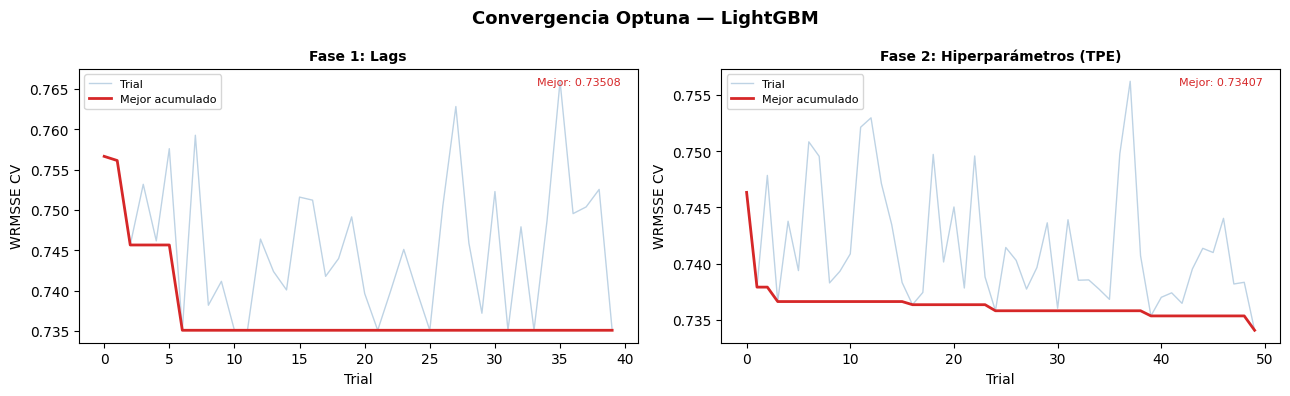

In [177]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Optuna convergence — LightGBM', fontweight='bold', fontsize=13)

for ax, study, title in zip(
    axes,
    [study_lags, study_main],
    ['Phase 1: Lags', 'Phase 2: Hyperparameters (TPE)']
):
    vals = [t.value for t in study.trials if t.value is not None]
    best = np.minimum.accumulate(vals)
    ax.plot(vals, alpha=0.35, color='steelblue', lw=1, label='Trial')
    ax.plot(best, color='#d62728', lw=2, label='Best so far')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Trial'); ax.set_ylabel('WRMSSE CV')
    ax.legend(fontsize=8)
    ax.text(0.97, 0.97, f'Best: {min(vals):.5f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            color='#d62728')

plt.tight_layout()
plt.savefig('outputs/optuna_lgbm_convergence.png', dpi=130, bbox_inches='tight')
plt.show() 

---

## **4. Comparison of all the models produced**

Next we plot the predictions of each model against the actual December 2015 results (the test set) for a selection of products.

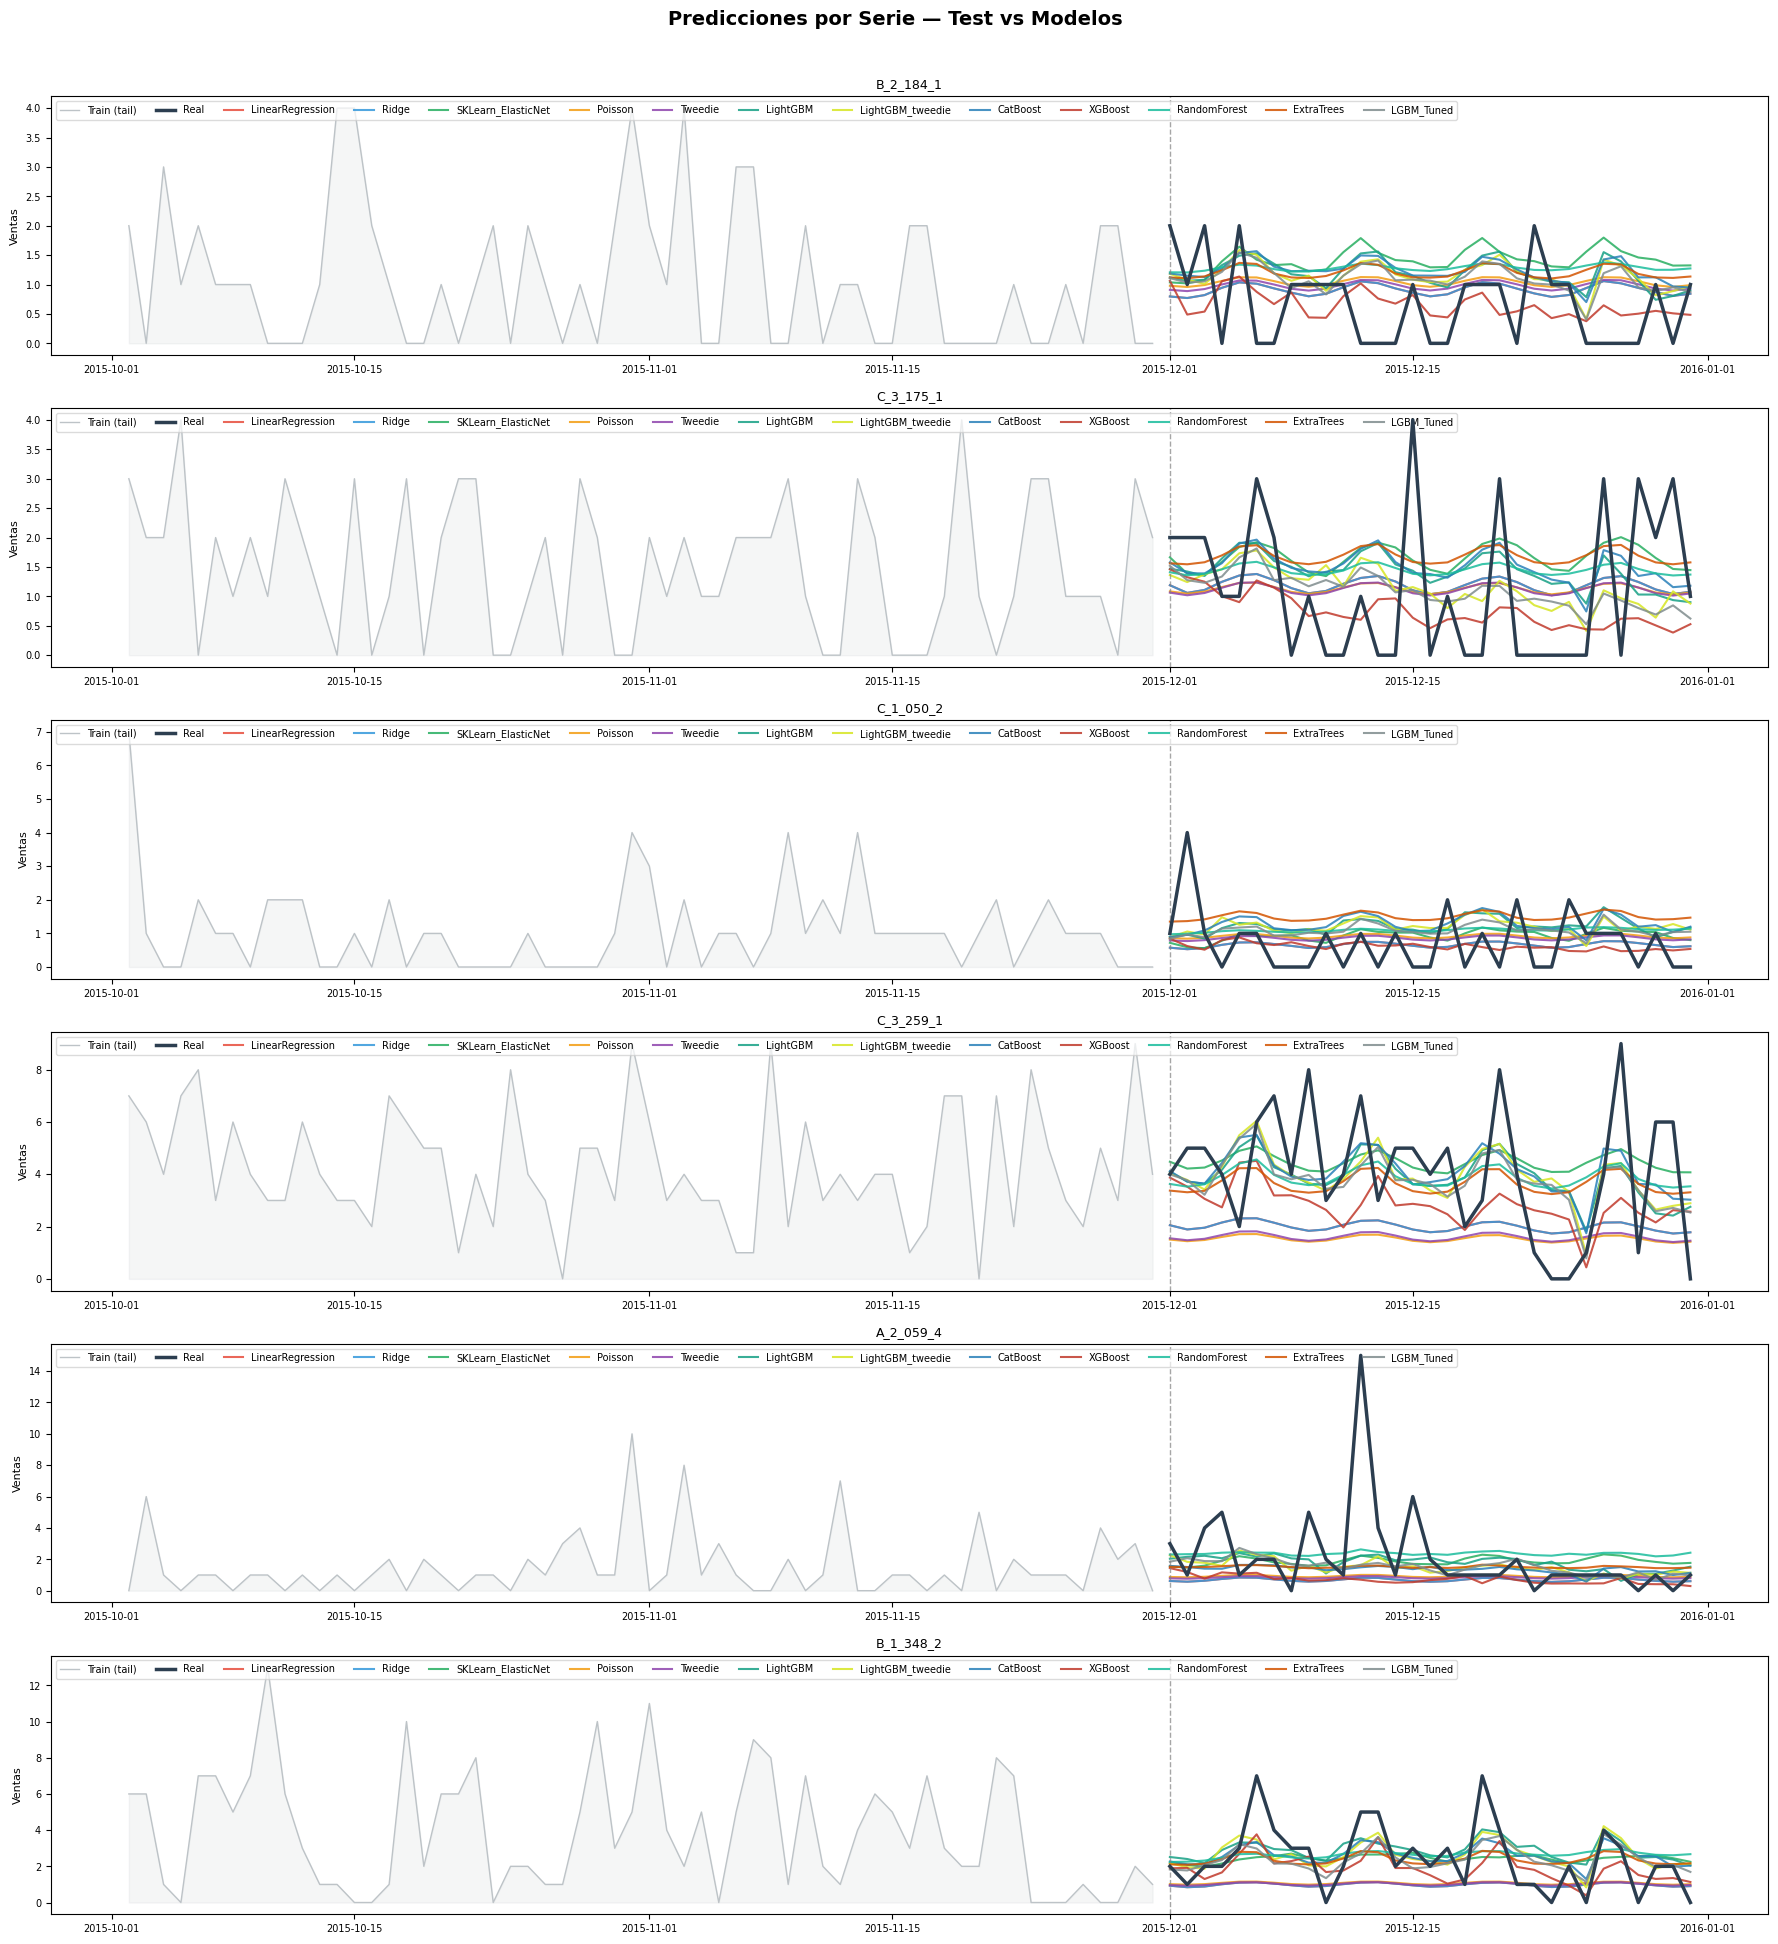

In [194]:
MODELS_TO_PLOT = list(ALL_FORECASTS.keys())
PALETTE = ['#E74C3C','#3498DB','#27AE60','#F39C12','#8E44AD','#16A085','#d6e622','#2980B9','#C0392B','#1ABC9C','#D35400','#7F8C8D']
COLOR_MAP  = {m: PALETTE[i % len(PALETTE)] for i, m in enumerate(MODELS_TO_PLOT)}
COLOR_REAL = '#2C3E50'
COLOR_TRAIN= '#BDC3C7'
N_TRAIN_SHOW = 60  
N_SERIES  = 6
sample_idx = random.sample(range(len(ts_test)), N_SERIES)

fig, axes = plt.subplots(N_SERIES, 1, figsize=(18, N_SERIES * 3.2))
fig.suptitle('Forecasts per Series — Test vs Models', fontsize=14, fontweight='bold', y=1.01)

for ax, idx in zip(axes, sample_idx):
    tr_tail = ts_train[idx][-N_TRAIN_SHOW:]
    ax.fill_between(tr_tail.time_index, tr_tail.values().flatten(),alpha=0.15, color=COLOR_TRAIN)
    ax.plot(tr_tail.time_index, tr_tail.values().flatten(),color=COLOR_TRAIN, lw=1, label='Train (tail)')
    yt = ts_test[idx]
    ax.plot(yt.time_index, yt.values().flatten(),color=COLOR_REAL, lw=2.5, label='Actual', zorder=10)
    for model_name in MODELS_TO_PLOT:
        preds = ALL_FORECASTS[model_name]
        if idx < len(preds):
            yp = preds[idx]
            n  = min(len(yt), len(yp))
            ax.plot(yp.time_index[:n], yp.values().flatten()[:n],color=COLOR_MAP[model_name], lw=1.5,alpha=0.85, label=model_name)

    ax.axvline(yt.time_index[0], color='gray', ls='--', lw=1, alpha=0.7)

    uid = list(ts_dict.keys())[idx] if 'ts_dict' in dir() else f'Series {idx}'
    ax.set_title(f'{uid}', fontsize=9)
    ax.set_ylabel('Sales', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, ncol=len(MODELS_TO_PLOT)+2,
              loc='upper left', framealpha=0.7)

plt.tight_layout()
plt.savefig('outputs/forecasts_per_series.png', dpi=130, bbox_inches='tight')
plt.show()

The predictions our model generates fall within the range of sales for nearly every series, although none of them is able to capture the intermittency seen in the actual results, since that is genuinely complex and largely random.

Next we compare the global sales predictions of each model.

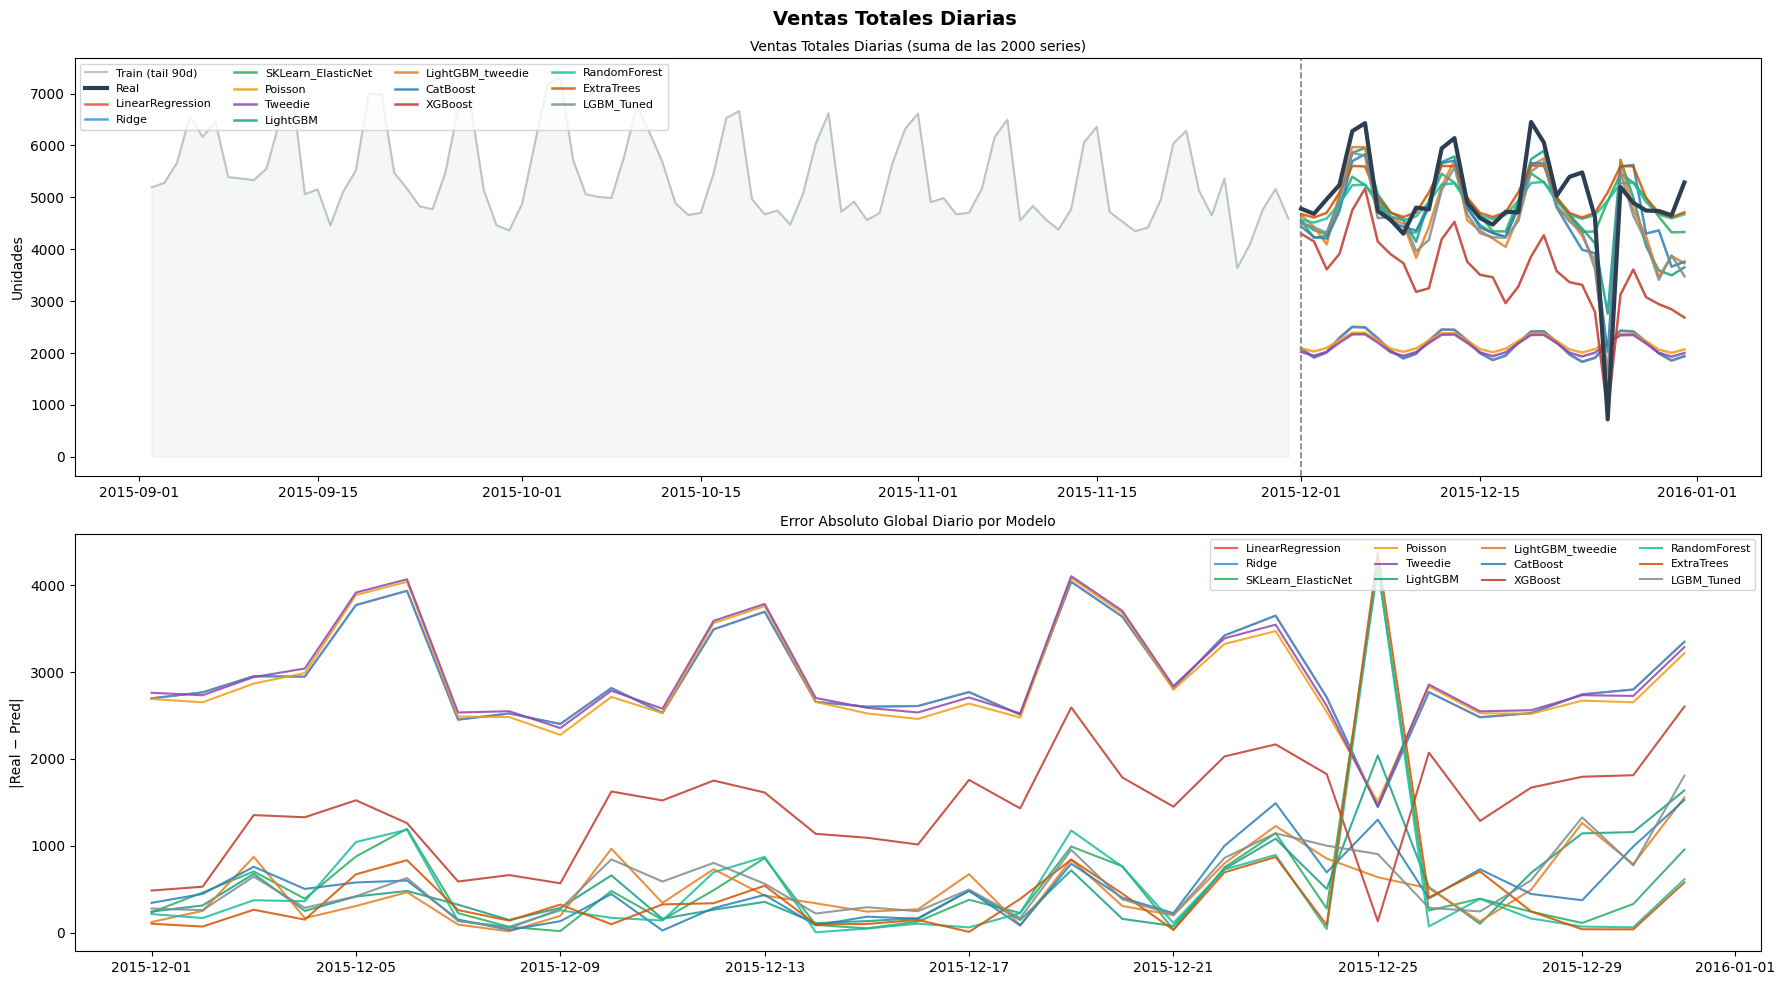

In [191]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))
fig.suptitle('Total Daily Sales', fontsize=14, fontweight='bold')

ax = axes[0]
train_total = pd.Series(data  = sum(ts.values().flatten() for ts in ts_train) [-90:],index = ts_train[0][-90:].time_index)
ax.fill_between(train_total.index, train_total.values,alpha=0.15, color=COLOR_TRAIN)
ax.plot(train_total.index, train_total.values,color=COLOR_TRAIN, lw=1.5, label='Train (tail 90d)')
test_total = pd.Series(data  = sum(ts.values().flatten() for ts in ts_test),index = ts_test[0].time_index,)
ax.plot(test_total.index, test_total.values,color=COLOR_REAL, lw=3, label='Actual', zorder=10)

for model_name in MODELS_TO_PLOT:
    preds = ALL_FORECASTS[model_name]
    n     = min(len(ts_test[0]), len(preds[0]))
    pred_total = sum(p.values().flatten()[:n] for p in preds)
    ax.plot(ts_test[0].time_index[:n], pred_total,color=COLOR_MAP[model_name], lw=1.8,alpha=0.85, label=model_name)
ax.axvline(ts_test[0].time_index[0], color='gray', ls='--', lw=1.2)
ax.set_title('Total Daily Sales (sum of the 2,000 series)', fontsize=10)
ax.set_ylabel('Units')
ax.legend(fontsize=8, ncol=4, loc='upper left', framealpha=0.8)


ax2 = axes[1]
for model_name in MODELS_TO_PLOT:
    preds = ALL_FORECASTS[model_name]
    n     = min(len(ts_test[0]), len(preds[0]))
    pred_total = sum(p.values().flatten()[:n] for p in preds)
    error      = np.abs(test_total.values[:n] - pred_total)
    ax2.plot(ts_test[0].time_index[:n], error,color=COLOR_MAP[model_name], lw=1.5,alpha=0.85, label=model_name)

ax2.set_title('Daily Global Absolute Error by Model', fontsize=10)
ax2.set_ylabel('|Actual − Pred|')
ax2.legend(fontsize=8, ncol=4, loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.savefig('outputs/forecasts_global.png', dpi=130, bbox_inches='tight')
plt.show()

Our model captures several of the complex oscillations that make up this forecast, which is genuinely difficult in this particular case because December is a rather special month in sales terms, as we saw in the EDA. In fact, we can see that the model correctly anticipates the drop in sales on Christmas Day. Its errors are also the lowest across this period.

Finally we rank the metrics obtained by the different models developed throughout this notebook by WRMSSE7 — the metric that compares every model against the naive model using a weekly naive predictor, which is the most appropriate one here. Using this metric lets us compare each model honestly against the baseline.

In [ ]:
metrics_df = (pd.DataFrame(ALL_METRICS).sort_values('WRMSSE7').reset_index(drop=True))
metrics_df.index += 1  

COLS_SHOW = ['Model', 'WRMSSE7', 'WRMSSE', 'RMSSE7', 'MASE', 'MAE', 'RMSLE', 'OPE']
best = metrics_df.iloc[0]

print('\n' + '='*80)
print('  FINAL RANKING — TEST (Dec 2015)  |  sorted by WRMSSE7'.center(80))
print('='*80)
print(metrics_df[COLS_SHOW].to_string(float_format=lambda x: f'{x:.4f}'))
print('='*80)
print(f'\n🥇 Best model : {best["Model"]}  (WRMSSE7 = {best["WRMSSE7"]:.4f})')


              FINAL RANKING — TEST (Dec 2015)  |  sorted by WRMSSE7             
                 Model  WRMSSE7  WRMSSE  RMSSE7   MASE    MAE  RMSLE     OPE
1           LGBM_Tuned   0.7717  0.7978  0.7078 0.7817 1.5722 0.5781 35.7577
2     LightGBM_tweedie   0.7861  0.8117  0.7137 0.7908 1.5938 0.5846 38.5734
3             LightGBM   0.7920  0.8181  0.7212 0.8060 1.6364 0.6017 41.9898
4             CatBoost   0.7931  0.8188  0.7196 0.8009 1.6240 0.5970 42.3960
5              XGBoost   0.7986  0.8247  0.7235 0.8112 1.6516 0.6075 43.4770
6         RandomForest   0.8068  0.8331  0.7280 0.8176 1.6633 0.6184 46.0081
7             CatBoost   0.8069  0.8328  0.7265 0.8114 1.6555 0.6093 43.5876
8              XGBoost   0.8173  0.8440  0.7376 0.7923 1.5949 0.5738 37.1613
9           ExtraTrees   0.8347  0.8617  0.7725 0.8912 1.7650 0.6589 69.1156
10  SKLearn_ElasticNet   0.8388  0.8645  0.7470 0.8415 1.6961 0.6237 43.5514
11               Ridge   1.1464  1.1827  0.8055 0.8779 2.0231 0.6568 46

---

## **5. Training the final model and generating the 2016 predictions**

Finally, to produce the future predictions for 2016 we have to use all the data we currently have, together with the complete series of the various past and future covariates. We therefore retrain the optimised model one last time.

In [196]:
lgbm_tuned = LightGBMModel(
    lags                   = BEST_LAGS,
    lags_future_covariates = [0],
    lags_past_covariates   = BEST_LAGS_PAST,
    output_chunk_length    = HORIZON,
    use_static_covariates  = True,

    objective              = 'tweedie',          
    tweedie_variance_power = vp_final,
    n_estimators           = 1500,
    learning_rate          = bp_final.get('learning_rate',      0.05),
    num_leaves             = num_leaves_final,
    max_depth              = max_depth_final,
    min_child_samples      = bp_final.get('min_child_samples',  50),
    min_child_weight       = bp_final.get('min_child_weight',   1.0),   
    min_gain_to_split      = bp_final.get('min_gain_to_split',  0.0),   
    reg_alpha              = bp_final.get('reg_alpha',          0.1),
    reg_lambda             = bp_final.get('reg_lambda',         0.5),
    subsample              = bp_final.get('subsample',          0.8),
    colsample_bytree       = bp_final.get('colsample_bytree',   0.8),
    colsample_bynode       = bp_final.get('colsample_bynode',   0.8),   
    random_state           = SEED,
    n_jobs                 = -1,
    verbose                = -1,
)

lgbm_tuned.fit(
    series            = ts_all,
    future_covariates = future_cov_list,
    past_covariates   = past_cov_list,
)
preds_jan2016 = lgbm_tuned.predict(
    n                 = HORIZON,
    series            = ts_all,
    future_covariates = future_cov_list,
    past_covariates   = past_cov_list,
)

We save all the predictions rounded to integers: although this may slightly alter the predictions the model generated (and lose some information), it is far more useful for the planning team to have whole numbers than a pile of decimals.

In [206]:
preds_jan2016 = [ts.map(lambda x: np.clip(x, 0, None)) for ts in preds_jan2016]

uids_ordered = list(ts_dict.keys())
rows = []
for i, uid in enumerate(uids_ordered):
    meta = META_DF[META_DF['unique_id']==uid].iloc[0]
    for date, val in zip(preds_jan2016[i].time_index, preds_jan2016[i].values().flatten()):
        rows.append({
            'id_':          uid,
            'product_id':   meta['product_id'],
            'subcat_id':    meta['subcat_id'],
            'cat_id':       meta['cat_id'],
            'store_id':     meta['store_id'],
            'snapshot_date': date.date(),
            'sales':        int(np.round(val)),
        })

df_output = (pd.DataFrame(rows).sort_values(['snapshot_date','cat_id','store_id','product_id']).reset_index(drop=True))
df_output.to_csv('outputs/predictions_jan2016.csv', index=True)